In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

scis1 = Image.open('../data/scis1.jpeg')
scis2 = Image.open('../data/scis2.jpeg')

# Local Image Descriptor

## Harris Local Image Descriptors

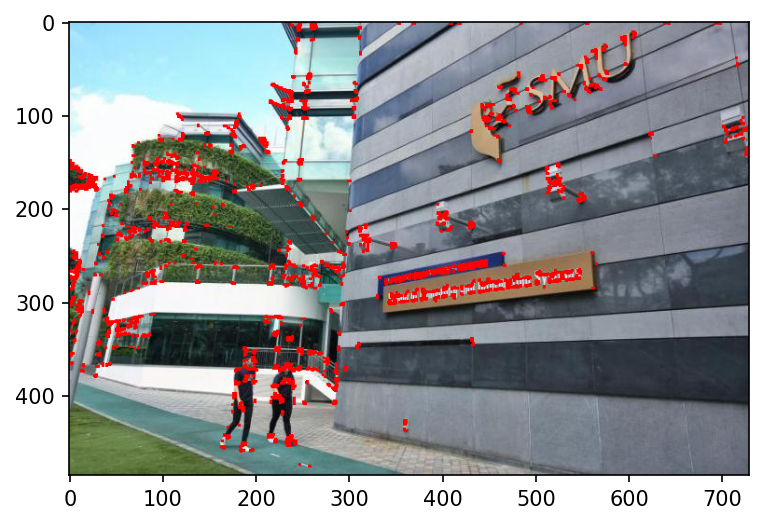

In [1]:
# Harris features
# https://docs.opencv.org/4.5.5/dc/d0d/tutorial_py_features_harris.html

import numpy as np
import matplotlib.pyplot as plt
import cv2

filename = '../data/scis1.jpeg'
img = cv2.imread(filename)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = np.float32(gray)
dst = cv2.cornerHarris(gray, 2, 3, 0.04)

#result is dilated for marking the corners, not important
dst = cv2.dilate(dst, None)

# Threshold for an optimal value, it may vary depending on the image.
img[dst > 0.01 * dst.max()] = [0, 0, 255]
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(dpi=150)
plt.imshow(img)
plt.show()

## SIFT Local Image Descriptors

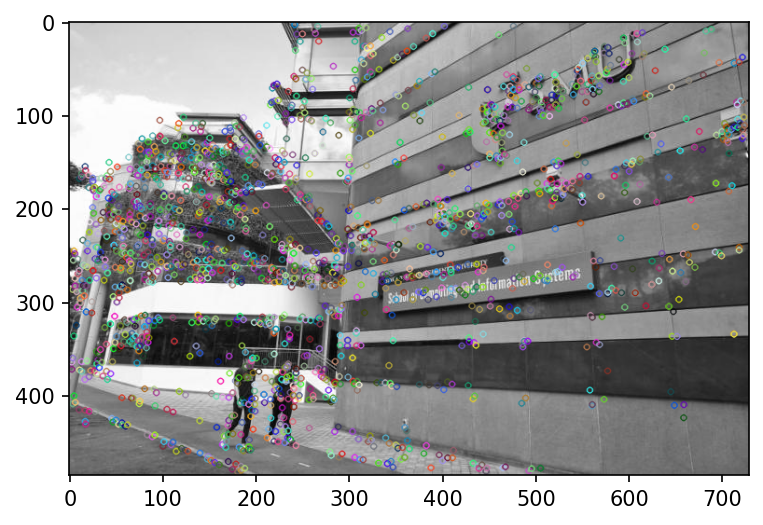

In [3]:
# SIFT
# https://docs.opencv.org/4.5.5/da/df5/tutorial_py_sift_intro.html
import numpy as np
import matplotlib.pyplot as plt
import cv2

filename = '../data/scis1.jpeg'
img = cv2.imread(filename)
gray= cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

sift = cv2.SIFT_create()
kp = sift.detect(gray,None)

img = cv2.drawKeypoints(gray, kp, img)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(dpi=150)
plt.imshow(img)
plt.show()

# Feature Matching

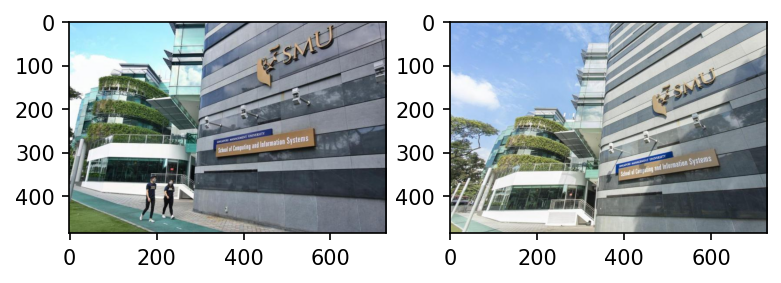

In [6]:
import matplotlib.pyplot as plt
from PIL import Image

scis1 = Image.open('../data/scis1.jpeg')
scis2 = Image.open('../data/scis2.jpeg')
fig, axs = plt.subplots(1, 2)
axs[0].imshow(scis1)
axs[1].imshow(scis2)

fig.set_dpi(150)
plt.show()

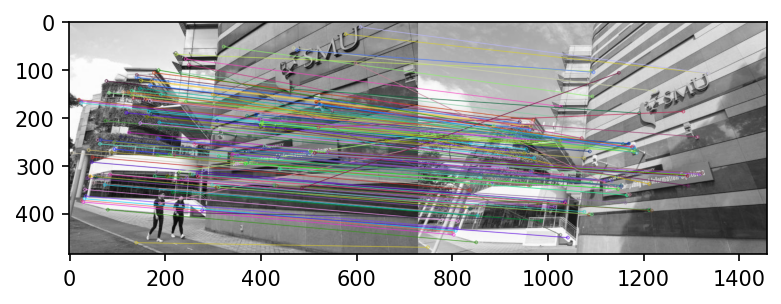

In [8]:
import cv2
import numpy as np

img1 = cv2.cvtColor(np.array(scis1), cv2.COLOR_RGB2GRAY)
img2 = cv2.cvtColor(np.array(scis2), cv2.COLOR_RGB2GRAY)

# Initiate SIFT detector
sift = cv2.SIFT_create()

# find the keypoints and descriptors with SIFT
kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)

# BFMatcher with default params
bf = cv2.BFMatcher()
matches = bf.knnMatch(des1,des2,k=2)

# Apply ratio test
good = []
for m,n in matches:
    if m.distance < 0.75 * n.distance:
        good.append([m])

# cv.drawMatchesKnn expects list of lists as matches.
img3 = cv2.drawMatchesKnn(img1, kp1, img2, kp2, good, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

plt.figure(dpi=150)
plt.imshow(img3)
plt.show()

# Projective Transformations and Homography

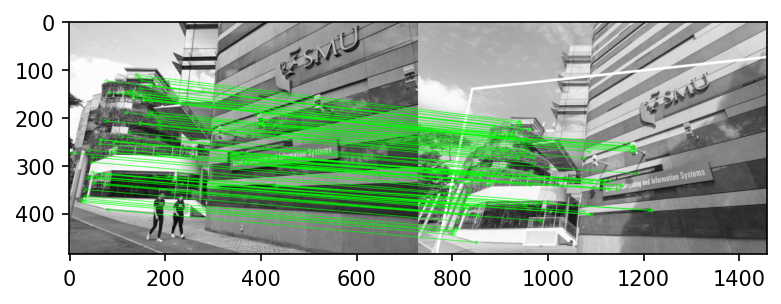

In [9]:
# https://docs.opencv.org/4.5.5/d1/de0/tutorial_py_feature_homography.html

import numpy as np
import cv2
import matplotlib.pyplot as plt

img1 = cv2.imread('../data/scis1.jpeg',cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('../data/scis2.jpeg', cv2.IMREAD_GRAYSCALE)

# Initiate SIFT detector
sift = cv2.SIFT_create()

# find the keypoints and descriptors with SIFT
kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)

# BFMatcher with default params
bf = cv2.BFMatcher()
matches = bf.knnMatch(des1,des2,k=2)

# Apply ratio test
good = []
for m,n in matches:
    if m.distance < 0.75 * n.distance:
        good.append(m)


#
src_pts = np.float32([ kp1[m.queryIdx].pt for m in good ]).reshape(-1,1,2)
dst_pts = np.float32([ kp2[m.trainIdx].pt for m in good ]).reshape(-1,1,2)
M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
matchesMask = mask.ravel().tolist()

h,w = img1.shape
pts = np.float32([[0,0], [0,h-1], [w-1,h-1], [w-1,0]]).reshape(-1,1,2)
dst = cv2.perspectiveTransform(pts, M)
img2 = cv2.polylines(img2,[np.int32(dst)],True,255,3, cv2.LINE_AA)

draw_params = dict(matchColor = (0,255,0), # draw matches in green color
                   singlePointColor = None,
                   matchesMask = matchesMask, # draw only inliers
                   flags = 2)

img3 = cv2.drawMatches(img1,kp1,img2,kp2,good,None,**draw_params)

plt.figure(dpi=150)
plt.imshow(img3)
plt.show()

## Warping

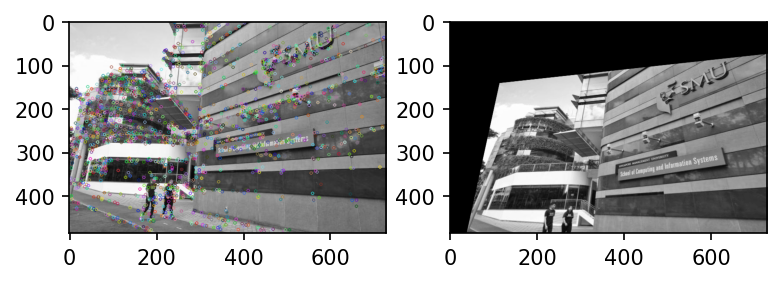

In [11]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

img1 = cv2.imread('../data/scis1.jpeg',cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('../data/scis2.jpeg', cv2.IMREAD_GRAYSCALE)

# Initiate SIFT detector
sift = cv2.SIFT_create()

# find the keypoints and descriptors with SIFT
kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)

# BFMatcher with default params
bf = cv2.BFMatcher()
matches = bf.knnMatch(des1,des2,k=2)

# Apply ratio test
good = []
for m,n in matches:
    if m.distance < 0.75 * n.distance:
        good.append(m)

src_pts = np.float32([ kp1[m.queryIdx].pt for m in good ]).reshape(-1,1,2)
dst_pts = np.float32([ kp2[m.trainIdx].pt for m in good ]).reshape(-1,1,2)
M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

dst = cv2.warpPerspective(img1, M, img2.shape[::-1])

plt.figure(dpi=150)
plt.subplot(121)
plt.imshow(img)

plt.subplot(122)
plt.imshow(dst, cmap='gray')
plt.show()

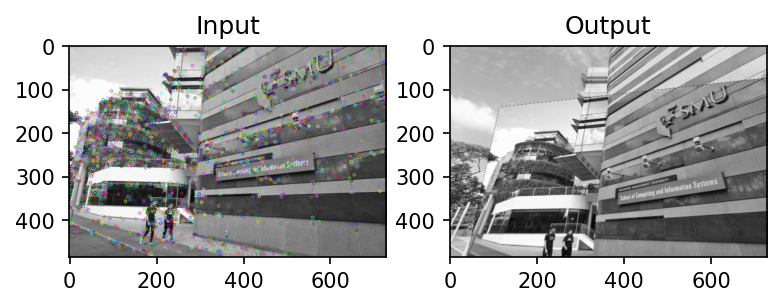

In [12]:
dst[dst == 0] = img2[dst == 0]
plt.figure(dpi=150)
plt.subplot(121)
plt.imshow(img)
plt.title('Input')

plt.subplot(122)
plt.imshow(dst, cmap='gray')
plt.title('Output')
plt.show()

# Misc

In [13]:
# Direct Linear Transform (Solem)
def H_from_points(fp, tp):
    m = np.mean(fp[:2], axis=1)
    maxstd = np.max(np.std(fp[:2], axis=1)) + 1e-9
    C1 = np.diag([1/maxstd, 1/maxstd, 1])
    C1[0][2] = -m[0] / maxstd
    C1[1][2] = -m[1] / maxstd
    fp = np.dot(C1, fp)

    m = np.mean(tp[:2], axis=1)
    maxstd = np.max(np.std(tp[:2], axis=1)) + 1e-9
    C2 = np.diag([1/maxstd, 1/maxstd, 1])
    C2[0][2] = -m[0] / maxstd
    C2[1][2] = -m[1] / maxstd
    tp = np.dot(C2, tp)

    nbr_correspondences = fp.shape[1]
    A = np.zeros((2 * nbr_correspondences, 9))
    for i in range(nbr_correspondences):
        A[2*i] = [-fp[0][i], -fp[1][i], -1, 0, 0, 0, tp[0][i] * fp[0][i], tp[0][i] * fp[1][i], tp[0][i]]
        A[2 * i+1] = [0, 0, 0, -fp[0][i], -fp[1][i], -1, tp[1][i] * fp[0][i], tp[1][i] * fp[1][i], tp[1][i]]

    U, S, V = np.linalg.svd(A)
    H = V[8].reshape((3, 3))
    H = np.dot(np.linalg.inv(C2), np.dot(H, C1))

    return H / H[2, 2]

pts1 = np.squeeze(src_pts)
pts2 = np.squeeze(dst_pts)
pts1 = np.array([(p[0], p[1], 1) for p in pts1])
pts2 = np.array([(p[0], p[1], 1) for p in pts2])
H_dlt = H_from_points(pts1.T, pts2.T)
H_dlt

array([[ 4.55820903e-01, -3.56972637e-01,  1.59630099e+02],
       [-1.49414159e-01,  3.62096921e-01,  1.50992700e+02],
       [-4.20210159e-04, -9.46399905e-04,  1.00000000e+00]])